In [1]:
# ============================================================
# CELL 1: Imports & CONFIG — RTX 4000 Lab Version
# ============================================================
import os, math, time, gc, random
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
import timm
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score

# CONFIG with batch_size=32 to yield exactly 1,058 batches per epoch
# num_workers=0 — avoids Windows multiprocessing deadlocks in interactive environments
CONFIG = {
    'data_dir'       : r'C:\ArtStyle_Project\new_subset',
    'checkpoint_dir' : r'C:\ArtStyle_Project\checkpoints_fresh',
    'image_size'     : 224,
    'batch_size'     : 32,   # Batch size 32 -> 1,058 batches per epoch
    'num_workers'    : 0,    # FIXED: always 0 on Windows
    'base_lr'        : 1e-3, # Full fresh-training LR for classifier head
    'weight_decay'   : 5e-4,
    'dropout'        : 0.5,
    'supcon_weight'  : 0.1,
    'epochs'         : 60
}

CLASS_NAMES = [
    'Art_Nouveau_Modern', 'Baroque', 'Cubism', 'Expressionism',
    'Impressionism', 'Realism', 'Romanticism'
]
num_classes = len(CLASS_NAMES)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}")
    print(f"VRAM   : {props.total_memory / 1e9:.1f} GB")

def fix_seeds(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_seeds(42)
os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
print("Config loaded.")

Device : cuda
GPU    : Quadro RTX 4000
VRAM   : 8.6 GB
Config loaded.


In [2]:
# ============================================================
# CELL 2: Scan Local Dataset
# ============================================================
class_counts = {}
all_paths    = []
all_labels   = []

assert os.path.exists(CONFIG['data_dir']), f"Dataset not found: {CONFIG['data_dir']}"

for idx, c_name in enumerate(CLASS_NAMES):
    c_dir  = os.path.join(CONFIG['data_dir'], c_name)
    count  = 0
    if os.path.exists(c_dir):
        for img_name in os.listdir(c_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_paths.append(os.path.join(c_dir, img_name))
                all_labels.append(idx)
                count += 1
    class_counts[c_name] = count

total_images = sum(class_counts.values())
max_count    = max(class_counts.values()) if class_counts else 1
min_count    = min(class_counts.values()) if class_counts else 1

print("Dataset Class Distribution:")
for c_name, count in class_counts.items():
    bar = chr(9608) * int(40 * count / max_count)
    print(f"  {c_name:<25} : {count:>6,} {bar}")

print(f"\nTotal          : {total_images:,}")
print(f"Classes        : {num_classes}")
print(f"Imbalance      : {max_count/min_count:.1f}x")
print("Dataset verified — safe to continue.")

Dataset Class Distribution:
  Art_Nouveau_Modern        :  4,334 █████████████
  Baroque                   :  4,240 ████████████
  Cubism                    :  2,235 ██████
  Expressionism             :  6,736 ████████████████████
  Impressionism             : 13,060 ████████████████████████████████████████
  Realism                   : 10,733 ████████████████████████████████
  Romanticism               :  7,019 █████████████████████

Total          : 48,357
Classes        : 7
Imbalance      : 5.8x
Dataset verified — safe to continue.


In [4]:
cache_file = r'C:\ArtStyle_Project\image_cache_7_classes_224.npy'
label_cache_file = r'C:\ArtStyle_Project\label_cache_7_classes_224.npy'

if os.path.exists(cache_file) and os.path.exists(label_cache_file):
    print(f"Cache file found - loading from disk...")
    # FIX: mmap_mode='r' intentionally kept - prevents Windows RAM thrashing
    # on machines where 7.5GB image array + PyTorch + GPU would exceed free RAM
    all_images = np.load(cache_file, mmap_mode='r')
    all_labels = np.load(label_cache_file)
    print(f"{len(all_images):,} images loaded from cache")
    print(f"Array size: ~{all_images.nbytes / (1024**3):.1f} GB (streamed via mmap)")
else:
    print(f"Building RAM cache for {total_images} images (this will take a while)...")
    all_images = np.zeros((total_images, 224, 224, 3), dtype=np.uint8)
    all_labels_arr = np.zeros(total_images, dtype=np.int32)

    idx_counter = 0
    for idx, c_name in enumerate(CLASS_NAMES):
        c_dir = os.path.join(CONFIG['data_dir'], c_name)
        if os.path.exists(c_dir):
            files = [f for f in os.listdir(c_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for img_name in tqdm(files, desc=f"Loading {c_name}", leave=False):
                img_path = os.path.join(c_dir, img_name)
                img = Image.open(img_path).convert('RGB').resize((224, 224))
                all_images[idx_counter] = np.array(img, dtype=np.uint8)
                all_labels_arr[idx_counter] = idx
                idx_counter += 1

    all_labels = all_labels_arr
    np.save(cache_file, all_images)
    np.save(label_cache_file, all_labels)
    print("\u2705 Cache built and saved to disk!")

Cache file found - loading from disk...
48,357 images loaded from cache
Array size: ~6.8 GB (streamed via mmap)


In [5]:
# ============================================================
# CELL 3: Splits + Augmentations + DataLoaders
# RAM-based pipeline — all_images array shared across splits
# ============================================================
from torch.utils.data import Dataset, DataLoader

# Stratified splits on indices — no data duplication in RAM
indices  = np.arange(total_images)

idx_temp, idx_test   = train_test_split(
    indices, test_size=0.15, stratify=all_labels_np, random_state=42
)
idx_train, idx_val   = train_test_split(
    idx_temp, test_size=0.1765, stratify=all_labels_np[idx_temp], random_state=42
)

print("Split sizes:")
print(f"  Train : {len(idx_train):,}")
print(f"  Val   : {len(idx_val):,}")
print(f"  Test  : {len(idx_test):,}")

# Class weights 1/sqrt(n)
class_weights = []
for c_name in CLASS_NAMES:
    n = class_counts.get(c_name, 1)
    class_weights.append(1.0 / math.sqrt(n))
class_weights = np.array(class_weights)
class_weights = class_weights / np.mean(class_weights)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("\nClass weights (1/sqrt(n)):")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:<25}: {class_weights[i]:.3f}  (n={class_counts.get(c,0):,})")


class ArtDataset(Dataset):
    """
    Reads images directly from RAM (all_images uint8 array).
    No disk I/O during training. Augmentation applied on-the-fly.
    """
    def __init__(self, all_images, indices, labels_np, class_names, split='train'):
        self.all_images  = all_images   # full RAM array — shared reference, not copied
        self.indices     = indices      # which rows belong to this split
        self.labels      = labels_np[indices]
        self.split       = split
        self.class_names = class_names
        self.normalize   = T.Normalize([0.485, 0.456, 0.406],
                                       [0.229, 0.224, 0.225])

        # 3-Tier differential augmentations
        self.tier1 = T.Compose([
            T.RandomHorizontalFlip(),
            T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
            T.ToTensor(), self.normalize
        ])
        self.tier2 = T.Compose([
            T.RandomResizedCrop(224, scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            T.ToTensor(), self.normalize
        ])
        self.tier3 = T.Compose([
            T.RandomResizedCrop(224, scale=(0.7, 1.0)),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.RandomRotation(20),
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
            T.RandomGrayscale(p=0.1),
            T.ToTensor(), self.normalize,
            T.RandomErasing(p=0.2)
        ])
        self.val_transform = T.Compose([
            T.ToTensor(), self.normalize
        ])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Read from RAM — no disk access
        img   = Image.fromarray(self.all_images[self.indices[idx]])
        label = int(self.labels[idx])

        if self.split != 'train':
            return self.val_transform(img), label

        c_name = self.class_names[label]
        if c_name in ['Impressionism', 'Expressionism', 'Romanticism', 'Realism']:
            return self.tier1(img), label
        elif c_name in ['Art_Nouveau_Modern', 'Baroque']:
            return self.tier2(img), label
        else:  # Cubism
            return self.tier3(img), label


# DataPrefetcher: CPU→GPU overlap
class DataPrefetcher:
    def __init__(self, loader):
        self.loader = iter(loader)
        self.stream = torch.cuda.Stream()
        self.preload()

    def preload(self):
        try:
            self.next_input, self.next_target = next(self.loader)
        except StopIteration:
            self.next_input = self.next_target = None
            return
        with torch.cuda.stream(self.stream):
            self.next_input  = self.next_input.to(DEVICE, non_blocking=True)
            self.next_target = self.next_target.to(DEVICE, non_blocking=True).long()

    def next(self):
        torch.cuda.current_stream().wait_stream(self.stream)
        inp, tgt = self.next_input, self.next_target
        if inp is not None:
            self.preload()
        return inp, tgt


# all_images is shared — no copies made
train_dataset = ArtDataset(all_images, idx_train, all_labels_np, CLASS_NAMES, split='train')
val_dataset   = ArtDataset(all_images, idx_val,   all_labels_np, CLASS_NAMES, split='val')
test_dataset  = ArtDataset(all_images, idx_test,  all_labels_np, CLASS_NAMES, split='test')

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=0, pin_memory=False)

print(f"\nDataLoaders ready — serving from RAM")
print(f"  Train batches : {len(train_loader):,}")
print(f"  Val batches   : {len(val_loader):,}")
print(f"  Test batches  : {len(test_loader):,}")

Split sizes:
  Train : 33,848
  Val   : 7,255
  Test  : 7,254

Class weights (1/sqrt(n)):
  Art_Nouveau_Modern       : 1.128  (n=4,334)
  Baroque                  : 1.141  (n=4,240)
  Cubism                   : 1.571  (n=2,235)
  Expressionism            : 0.905  (n=6,736)
  Impressionism            : 0.650  (n=13,060)
  Realism                  : 0.717  (n=10,733)
  Romanticism              : 0.887  (n=7,019)

DataLoaders ready — serving from RAM
  Train batches : 1,058
  Val batches   : 227
  Test batches  : 227


In [6]:
# ============================================================
# CELL 4: Model Architecture (ResNet50 + ViT-Small + Adaptive Fusion)
# ============================================================

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=kernel_size,
                                 padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class AdaptiveFusion(nn.Module):
    def __init__(self, cnn_dim=2048, vit_dim=384, out_dim=512):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, out_dim)
        self.vit_proj = nn.Linear(vit_dim, out_dim)
        self.gate = nn.Sequential(
            nn.Linear(out_dim * 2, out_dim), nn.ReLU(),
            nn.Linear(out_dim, 2)
        )

    def forward(self, cnn_feat, vit_feat):
        if len(cnn_feat.shape) > 2: cnn_feat = torch.flatten(cnn_feat, 1)
        if len(vit_feat.shape) > 2: vit_feat = vit_feat[:, 0]
        c = self.cnn_proj(cnn_feat)
        v = self.vit_proj(vit_feat)
        g = torch.softmax(self.gate(torch.cat([c, v], dim=1)), dim=1)
        return g[:, 0:1] * c + g[:, 1:2] * v


class ArtStyleHybrid(nn.Module):
    def __init__(self, num_classes=7, dropout=0.5):
        super().__init__()
        resnet = models.resnet50(weights='IMAGENET1K_V2')
        self.cnn_features = nn.Sequential(*list(resnet.children())[:-2])

        # Freeze only the stem (conv1 + bn1) — universal edge detectors
        for i in [0, 1]:
            for p in self.cnn_features[i].parameters():
                p.requires_grad = False

        self.cnn_spatial_att = SpatialAttention()
        self.cnn_pool        = nn.AdaptiveAvgPool2d((1, 1))
        self.vit             = timm.create_model('vit_small_patch16_224',
                                                  pretrained=True, num_classes=0)
        self.fusion          = AdaptiveFusion(cnn_dim=2048, vit_dim=384, out_dim=512)
        self.classifier      = nn.Sequential(
            nn.LayerNorm(512), nn.Linear(512, 256),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(256, num_classes)
        )

    def forward(self, x):
        cnn_map = self.cnn_features(x)
        cnn_att = self.cnn_spatial_att(cnn_map)
        cnn_out = torch.flatten(self.cnn_pool(cnn_att), 1)
        vit_out = self.vit(x)
        fused   = self.fusion(cnn_out, vit_out)
        return self.classifier(fused), fused


model = ArtStyleHybrid(num_classes=num_classes, dropout=CONFIG['dropout']).to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready on {DEVICE}")
print(f"  Total params     : {total_p:,}")
print(f"  Trainable params : {trainable_p:,} ({100*trainable_p/total_p:.1f}%)")
print(f"  Frozen params    : {total_p - trainable_p:,}")

Model ready on cuda
  Total params     : 47,079,979
  Trainable params : 47,070,443 (100.0%)
  Frozen params    : 9,536


In [7]:
# ============================================================
# CELL 5: Checkpoint Loading — Latest first, Best as fallback
# ============================================================
import os

latest_path = os.path.join(CONFIG['checkpoint_dir'], 'latest_checkpoint_7_classes_v2.pt')
best_path   = os.path.join(CONFIG['checkpoint_dir'], 'best_model_7_classes_v2.pt')
# Also check for original best_model.pt (from Drive)
orig_best   = os.path.join(CONFIG['checkpoint_dir'], 'best_model.pt')
orig_best2  = os.path.join(CONFIG['checkpoint_dir'], 'best_model (2).pt')

start_epoch   = 1
best_val_loss = float('inf')
checkpoint    = None

if os.path.exists(latest_path):
    print(f"Loading latest checkpoint: {latest_path}")
    checkpoint = torch.load(latest_path, map_location=DEVICE)
elif os.path.exists(best_path):
    print(f"Latest not found. Loading best checkpoint: {best_path}")
    checkpoint = torch.load(best_path, map_location=DEVICE)
elif os.path.exists(orig_best):
    print(f"Loading original best_model.pt: {orig_best}")
    checkpoint = torch.load(orig_best, map_location=DEVICE)
elif os.path.exists(orig_best2):
    print(f"Loading best_model (2).pt: {orig_best2}")
    checkpoint = torch.load(orig_best2, map_location=DEVICE)
else:
    print("No checkpoint found — starting from scratch (Epoch 1).")

if checkpoint is not None:
    status = model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    print(f"  Missing keys  : {len(status.missing_keys)}")
    print(f"  Unexpected    : {len(status.unexpected_keys)}")
    start_epoch   = checkpoint.get('epoch', 0) + 1
    best_val_loss = checkpoint.get('best_val_loss',
                    checkpoint.get('val_loss', float('inf')))
    history       = checkpoint.get('history', {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'train_f1', 'val_f1']})
    print(f"  Loaded epoch  : {start_epoch - 1}")
    print(f"  Best val_loss : {best_val_loss:.4f}")
    print(f"  History size  : {len(history.get('train_loss', []))} epochs restored")
    print(f"  Resuming from : epoch {start_epoch}")
else:
    history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'train_f1', 'val_f1']}


Loading latest checkpoint: C:\ArtStyle_Project\checkpoints_fresh\latest_checkpoint_7_classes_v2.pt


C:\Users\Admin\AppData\Local\Temp\ipykernel_3320\660807435.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_path, map_location=DEVICE)


  Missing keys  : 0
  Unexpected    : 0
  Loaded epoch  : 50
  Best val_loss : 1.0755
  History size  : 31 epochs restored
  Resuming from : epoch 51


In [8]:
# ============================================================
# CELL 6: Loss Functions + Optimizer (LLRD) + Scheduler
# ============================================================

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device   = features.device
        features = torch.nn.functional.normalize(features, dim=1)
        sim      = torch.matmul(features, features.T) / self.temperature
        sim_max, _ = sim.max(dim=1, keepdim=True)
        sim      = sim - sim_max.detach()
        labels   = labels.view(-1, 1)
        pos_mask = (labels == labels.T).float()
        self_mask = torch.eye(features.shape[0], device=device)
        pos_mask  = pos_mask - self_mask
        exp_sim   = torch.exp(sim) * (1 - self_mask)
        log_prob  = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)
        num_pos   = pos_mask.sum(dim=1)
        loss      = -(pos_mask * log_prob).sum(dim=1) / (num_pos + 1e-8)
        valid     = num_pos > 0
        if valid.sum() == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)
        return loss[valid].mean()


criterion_ce = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
criterion_sc = SupConLoss()

optimizer = torch.optim.AdamW([
    {'params': filter(lambda p: p.requires_grad,
                      model.cnn_features.parameters()), 'lr': 1e-5},
    {'params': model.cnn_spatial_att.parameters(), 'lr': 1e-4},
    {'params': model.vit.parameters(),             'lr': 1e-5},
    {'params': model.fusion.parameters(),          'lr': 5e-4},
    {'params': model.classifier.parameters(),      'lr': CONFIG['base_lr']}
], weight_decay=CONFIG['weight_decay'])

if checkpoint is not None and 'optimizer_state_dict' in checkpoint:
    try:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print("Optimizer state loaded.")
    except:
        print("Optimizer state mismatch — using fresh optimizer.")

# ── CHANGED: CosineAnnealingWarmRestarts → ReduceLROnPlateau ──
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-7
)

# NOTE: Do NOT load old scheduler state — it belongs to the old scheduler type
# and will cause a crash or wrong behaviour if loaded here
if checkpoint is not None and 'scheduler_state_dict' in checkpoint:
    print("Skipping old scheduler state (switching scheduler type).")

print(f"\nLoss: CrossEntropy(label_smooth=0.1) + {CONFIG['supcon_weight']}xSupCon")
print(f"Optimizer: AdamW with LLRD")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=3, min_lr=1e-7)")

Optimizer state loaded.
Skipping old scheduler state (switching scheduler type).

Loss: CrossEntropy(label_smooth=0.1) + 0.1xSupCon
Optimizer: AdamW with LLRD
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3, min_lr=1e-7)


In [9]:
# ============================================================
# CELL 7: Training Loop — RTX 4000
# base_lr=1e-3 | DataPrefetcher | batch logging every 50 batches
# ============================================================
import time
from sklearn.metrics import f1_score, accuracy_score

patience   = 10
no_improve = 0

print("=" * 60)
print(f"TRAINING  — epochs {start_epoch} to {CONFIG['epochs']}")
print(f"Base LR   : {CONFIG['base_lr']}  | WD : {CONFIG['weight_decay']}")
print(f"Batch     : {CONFIG['batch_size']} (RTX 4000 8GB safe)")
print(f"Dropout   : {CONFIG['dropout']}   | Patience : {patience}")
print(f"Prefetcher: DataPrefetcher (GPU overlap)")
print("=" * 60)

for epoch in range(start_epoch, CONFIG['epochs'] + 1):
    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    total_loss = ce_loss_sum = sc_loss_sum = 0.0
    all_preds, all_targets = [], []
    t0 = time.time()

    prefetcher   = DataPrefetcher(train_loader)
    imgs, labels = prefetcher.next()
    batch_idx    = 0

    while imgs is not None:
        optimizer.zero_grad()

        logits, fused = model(imgs)
        loss_ce = criterion_ce(logits, labels)
        loss_sc = criterion_sc(fused, labels)
        loss    = loss_ce + CONFIG['supcon_weight'] * loss_sc

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss  += loss.item()
        ce_loss_sum += loss_ce.item()
        sc_loss_sum += loss_sc.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

        if batch_idx % 50 == 0:
            print(f"  Batch {batch_idx:>4}/{len(train_loader)} | "
                  f"Loss:{loss.item():.4f} "
                  f"CE:{loss_ce.item():.4f} "
                  f"SC:{loss_sc.item():.4f}")

        imgs, labels = prefetcher.next()
        batch_idx   += 1

    train_acc  = accuracy_score(all_targets, all_preds)
    train_f1   = f1_score(all_targets, all_preds, average='macro')
    train_loss = total_loss / len(train_loader)

    # ── VALIDATE ────────────────────────────────────────────
    model.eval()
    val_loss   = 0.0
    val_preds, val_targets = [], []

    val_pf       = DataPrefetcher(val_loader)
    imgs, labels = val_pf.next()

    with torch.no_grad():
        while imgs is not None:
            logits, fused = model(imgs)
            lce      = criterion_ce(logits, labels)
            lsc      = criterion_sc(fused, labels)
            val_loss += (lce + CONFIG['supcon_weight'] * lsc).item()
            val_preds.extend(torch.argmax(logits, 1).cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            imgs, labels = val_pf.next()

    val_loss /= len(val_loader)
    val_acc   = accuracy_score(val_targets, val_preds)
    val_f1    = f1_score(val_targets, val_preds, average='macro')

    # ── SCHEDULER STEP — capture LR before and after ────────
    lr_before = optimizer.param_groups[-1]['lr']
    scheduler.step(val_loss)
    lr_after  = optimizer.param_groups[-1]['lr']

    # ── RESTORE BEST WEIGHTS if LR was just reduced ─────────
    best_ckpt   = os.path.join(CONFIG['checkpoint_dir'], 'best_model.pt')
    latest_ckpt = os.path.join(
        CONFIG['checkpoint_dir'], 'latest_checkpoint_7_classes_v2.pt')

    if lr_after < lr_before:
        if os.path.exists(best_ckpt):
            best_weights = torch.load(
                best_ckpt, map_location=DEVICE, weights_only=False)
            model.load_state_dict(best_weights['model_state_dict'])
            print(f"  LR reduced {lr_before:.2e} → {lr_after:.2e} "
                  f"| Best weights restored from best_model.pt")
        else:
            print(f"  LR reduced {lr_before:.2e} → {lr_after:.2e} "
                  f"| No best checkpoint yet, keeping current weights")

    gap = (train_acc - val_acc) * 100

    print(f"\nEpoch [{epoch}/{CONFIG['epochs']}] ({time.time()-t0:.0f}s)")
    print(f"  Train -> Loss:{train_loss:.4f}  "
          f"Acc:{train_acc:.4f}  F1:{train_f1:.4f}")
    print(f"  Val   -> Loss:{val_loss:.4f}  "
          f"Acc:{val_acc:.4f}  F1:{val_f1:.4f}")
    print(f"  Gap   -> {gap:.1f}%  |  LR: {lr_after:.2e}")

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    # ── CHECKPOINT DATA ───────────────────────────────────
    ckpt_data = {
        'epoch'               : epoch,
        'model_state_dict'    : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_loss'            : val_loss,
        'val_acc'             : val_acc,
        'val_f1'              : val_f1,
        'best_val_loss'       : best_val_loss,
        'history'             : history
    }

    # ── BEST MODEL ────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss          = val_loss
        no_improve             = 0
        ckpt_data['best_val_loss'] = best_val_loss
        torch.save(ckpt_data, best_ckpt)
        mb = os.path.getsize(best_ckpt) / 1e6
        print(f"  Best model saved ({mb:.0f} MB) "
              f"→ best_model.pt | val_loss: {best_val_loss:.4f}")
    else:
        no_improve += 1
        print(f"  No improvement {no_improve}/{patience}")

    # ── LATEST CHECKPOINT ─────────────────────────────────
    torch.save(ckpt_data, latest_ckpt)
    mb = os.path.getsize(latest_ckpt) / 1e6
    print(f"  Latest checkpoint saved ({mb:.0f} MB) "
          f"→ latest_checkpoint_7_classes_v2.pt")

    # ── GAP CHECKPOINT — saved when gap < 10% ─────────────
    # These are rare and valuable — model generalising well
    if gap < 10.0:
        gap_ckpt = os.path.join(
            CONFIG['checkpoint_dir'],
            f'gap_under10_epoch{epoch}.pt')
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'val_acc'          : val_acc,
            'val_loss'         : val_loss,
            'train_acc'        : train_acc,
            'gap'              : gap
        }, gap_ckpt)
        print(f"  Gap {gap:.1f}% < 10% — "
              f"checkpoint saved: gap_under10_epoch{epoch}.pt")

    # ── EARLY STOPPING ────────────────────────────────────
    if no_improve >= patience:
        print("\nEarly stopping triggered!")
        break

print("\nTraining complete.")

TRAINING  — epochs 51 to 60
Base LR   : 0.001  | WD : 0.0005
Batch     : 32 (RTX 4000 8GB safe)
Dropout   : 0.5   | Patience : 10
Prefetcher: DataPrefetcher (GPU overlap)
  Batch    0/1058 | Loss:0.8044 CE:0.6029 SC:2.0148
  Batch   50/1058 | Loss:0.7216 CE:0.5489 SC:1.7264
  Batch  100/1058 | Loss:0.8066 CE:0.5823 SC:2.2432
  Batch  150/1058 | Loss:0.8417 CE:0.6444 SC:1.9726
  Batch  200/1058 | Loss:0.7423 CE:0.5602 SC:1.8206
  Batch  250/1058 | Loss:0.7198 CE:0.5315 SC:1.8830
  Batch  300/1058 | Loss:0.7379 CE:0.5586 SC:1.7932
  Batch  350/1058 | Loss:0.8497 CE:0.6359 SC:2.1383
  Batch  400/1058 | Loss:0.8002 CE:0.5971 SC:2.0313
  Batch  450/1058 | Loss:0.8075 CE:0.6149 SC:1.9264
  Batch  500/1058 | Loss:0.9147 CE:0.6722 SC:2.4250
  Batch  550/1058 | Loss:0.7441 CE:0.5666 SC:1.7751
  Batch  600/1058 | Loss:0.7404 CE:0.5674 SC:1.7302
  Batch  650/1058 | Loss:0.7630 CE:0.5777 SC:1.8530
  Batch  700/1058 | Loss:0.7226 CE:0.5355 SC:1.8711
  Batch  750/1058 | Loss:0.7757 CE:0.5780 SC:1.97

KeyboardInterrupt: 

In [12]:
# ============================================================
# CELL 7: Training Loop — RTX 4000
# base_lr=1e-3 | DataPrefetcher | batch logging every 50 batches
# LR halved + best weights restored every 3 epochs no-improve
# ============================================================
import time
from sklearn.metrics import f1_score, accuracy_score

patience   = 10
no_improve = 0

print("=" * 60)
print(f"TRAINING  — epochs {start_epoch} to {CONFIG['epochs']}")
print(f"Base LR   : {CONFIG['base_lr']}  | WD : {CONFIG['weight_decay']}")
print(f"Batch     : {CONFIG['batch_size']} (RTX 4000 8GB safe)")
print(f"Dropout   : {CONFIG['dropout']}   | Patience : {patience}")
print(f"Prefetcher: DataPrefetcher (GPU overlap)")
print(f"LR reduce : ×0.5 every 3 epochs of no improvement")
print(f"Restore   : best weights on every LR reduction")
print("=" * 60)

for epoch in range(start_epoch, CONFIG['epochs'] + 1):
    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    total_loss = ce_loss_sum = sc_loss_sum = 0.0
    all_preds, all_targets = [], []
    t0 = time.time()

    prefetcher   = DataPrefetcher(train_loader)
    imgs, labels = prefetcher.next()
    batch_idx    = 0

    while imgs is not None:
        optimizer.zero_grad()

        logits, fused = model(imgs)
        loss_ce = criterion_ce(logits, labels)
        loss_sc = criterion_sc(fused, labels)
        loss    = loss_ce + CONFIG['supcon_weight'] * loss_sc

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss  += loss.item()
        ce_loss_sum += loss_ce.item()
        sc_loss_sum += loss_sc.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

        if batch_idx % 50 == 0:
            print(f"  Batch {batch_idx:>4}/{len(train_loader)} | "
                  f"Loss:{loss.item():.4f} "
                  f"CE:{loss_ce.item():.4f} "
                  f"SC:{loss_sc.item():.4f}")

        imgs, labels = prefetcher.next()
        batch_idx   += 1

    train_acc  = accuracy_score(all_targets, all_preds)
    train_f1   = f1_score(all_targets, all_preds, average='macro')
    train_loss = total_loss / len(train_loader)

    # ── VALIDATE ────────────────────────────────────────────
    model.eval()
    val_loss   = 0.0
    val_preds, val_targets = [], []

    val_pf       = DataPrefetcher(val_loader)
    imgs, labels = val_pf.next()

    with torch.no_grad():
        while imgs is not None:
            logits, fused = model(imgs)
            lce      = criterion_ce(logits, labels)
            lsc      = criterion_sc(fused, labels)
            val_loss += (lce + CONFIG['supcon_weight'] * lsc).item()
            val_preds.extend(torch.argmax(logits, 1).cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            imgs, labels = val_pf.next()

    val_loss /= len(val_loader)
    val_acc   = accuracy_score(val_targets, val_preds)
    val_f1    = f1_score(val_targets, val_preds, average='macro')

    gap       = (train_acc - val_acc) * 100
    lr_now    = optimizer.param_groups[-1]['lr']

    print(f"\nEpoch [{epoch}/{CONFIG['epochs']}] ({time.time()-t0:.0f}s)")
    print(f"  Train -> Loss:{train_loss:.4f}  "
          f"Acc:{train_acc:.4f}  F1:{train_f1:.4f}")
    print(f"  Val   -> Loss:{val_loss:.4f}  "
          f"Acc:{val_acc:.4f}  F1:{val_f1:.4f}")
    print(f"  Gap   -> {gap:.1f}%  |  LR: {lr_now:.2e}")

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    best_ckpt   = os.path.join(CONFIG['checkpoint_dir'], 'best_model.pt')
    latest_ckpt = os.path.join(
        CONFIG['checkpoint_dir'], 'latest_checkpoint_7_classes_v2.pt')

    # ── CHECKPOINT DATA ───────────────────────────────────
    ckpt_data = {
        'epoch'               : epoch,
        'model_state_dict'    : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss'            : val_loss,
        'val_acc'             : val_acc,
        'val_f1'              : val_f1,
        'best_val_loss'       : best_val_loss,
        'history'             : history
    }

    # ── BEST MODEL ────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss              = val_loss
        no_improve                 = 0
        ckpt_data['best_val_loss'] = best_val_loss
        torch.save(ckpt_data, best_ckpt)
        mb = os.path.getsize(best_ckpt) / 1e6
        print(f"  ✓ Best model saved ({mb:.0f} MB) "
              f"→ best_model.pt | val_loss: {best_val_loss:.4f}")

    # ── NO IMPROVEMENT — LR halve + restore every 3 epochs ───
    else:
        no_improve += 1
        print(f"  No improvement {no_improve}/{patience}")

        if no_improve % 3 == 0:
            lr_before = optimizer.param_groups[-1]['lr']
            for pg in optimizer.param_groups:
                pg['lr'] = pg['lr'] * 0.5
            lr_after = optimizer.param_groups[-1]['lr']

            if os.path.exists(best_ckpt):
                best_weights = torch.load(
                    best_ckpt, map_location=DEVICE, weights_only=False)
                model.load_state_dict(best_weights['model_state_dict'])
                print(f"  ↩ {no_improve}/3 no-improve — "
                      f"LR {lr_before:.2e} → {lr_after:.2e} | "
                      f"best weights restored "
                      f"(val_loss: {best_val_loss:.4f})")
            else:
                print(f"  ↩ {no_improve}/3 no-improve — "
                      f"LR {lr_before:.2e} → {lr_after:.2e} | "
                      f"no checkpoint yet, keeping current weights")

    # ── LATEST CHECKPOINT ─────────────────────────────────
    torch.save(ckpt_data, latest_ckpt)
    mb = os.path.getsize(latest_ckpt) / 1e6
    print(f"  Latest checkpoint saved ({mb:.0f} MB) "
          f"→ latest_checkpoint_7_classes_v2.pt")

    # ── GAP CHECKPOINT — saved when gap < 10% ─────────────
    if gap < 10.0:
        gap_ckpt = os.path.join(
            CONFIG['checkpoint_dir'],
            f'gap_under10_epoch{epoch}.pt')
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model.state_dict(),
            'val_acc'         : val_acc,
            'val_loss'        : val_loss,
            'train_acc'       : train_acc,
            'gap'             : gap,
            'val_preds'       : val_preds,    # ← for confusion matrix
            'val_targets'     : val_targets   # ← for confusion matrix
        }, gap_ckpt)
        print(f"  Gap {gap:.1f}% < 10% — "
              f"checkpoint saved: gap_under10_epoch{epoch}.pt")

    # ── EARLY STOPPING ────────────────────────────────────
    if no_improve >= patience:
        print("\nEarly stopping triggered!")
        break

print("\nTraining complete.")

TRAINING  — epochs 51 to 60
Base LR   : 0.001  | WD : 0.0005
Batch     : 32 (RTX 4000 8GB safe)
Dropout   : 0.5   | Patience : 10
Prefetcher: DataPrefetcher (GPU overlap)
LR reduce : ×0.5 every 3 epochs of no improvement
Restore   : best weights on every LR reduction
  Batch    0/1058 | Loss:1.1649 CE:0.8995 SC:2.6540
  Batch   50/1058 | Loss:0.9302 CE:0.7050 SC:2.2521
  Batch  100/1058 | Loss:0.8765 CE:0.6796 SC:1.9689
  Batch  150/1058 | Loss:1.2756 CE:0.9898 SC:2.8580
  Batch  200/1058 | Loss:1.1799 CE:0.8829 SC:2.9699
  Batch  250/1058 | Loss:1.0217 CE:0.7692 SC:2.5251
  Batch  300/1058 | Loss:1.0678 CE:0.8127 SC:2.5506
  Batch  350/1058 | Loss:0.8865 CE:0.6745 SC:2.1200
  Batch  400/1058 | Loss:1.0538 CE:0.7982 SC:2.5560
  Batch  450/1058 | Loss:1.2094 CE:0.9517 SC:2.5771
  Batch  500/1058 | Loss:1.2688 CE:0.9920 SC:2.7683
  Batch  550/1058 | Loss:0.8326 CE:0.6259 SC:2.0670
  Batch  600/1058 | Loss:0.8788 CE:0.6632 SC:2.1568
  Batch  650/1058 | Loss:0.9851 CE:0.7539 SC:2.3119
  Ba

KeyboardInterrupt: 

best_model.pt | epoch 30 | test_acc 70.80% | F1 0.7122
latest_checkpoint_7_classes_v2.pt | epoch 51 | test_acc 70.20% | F1 0.6582


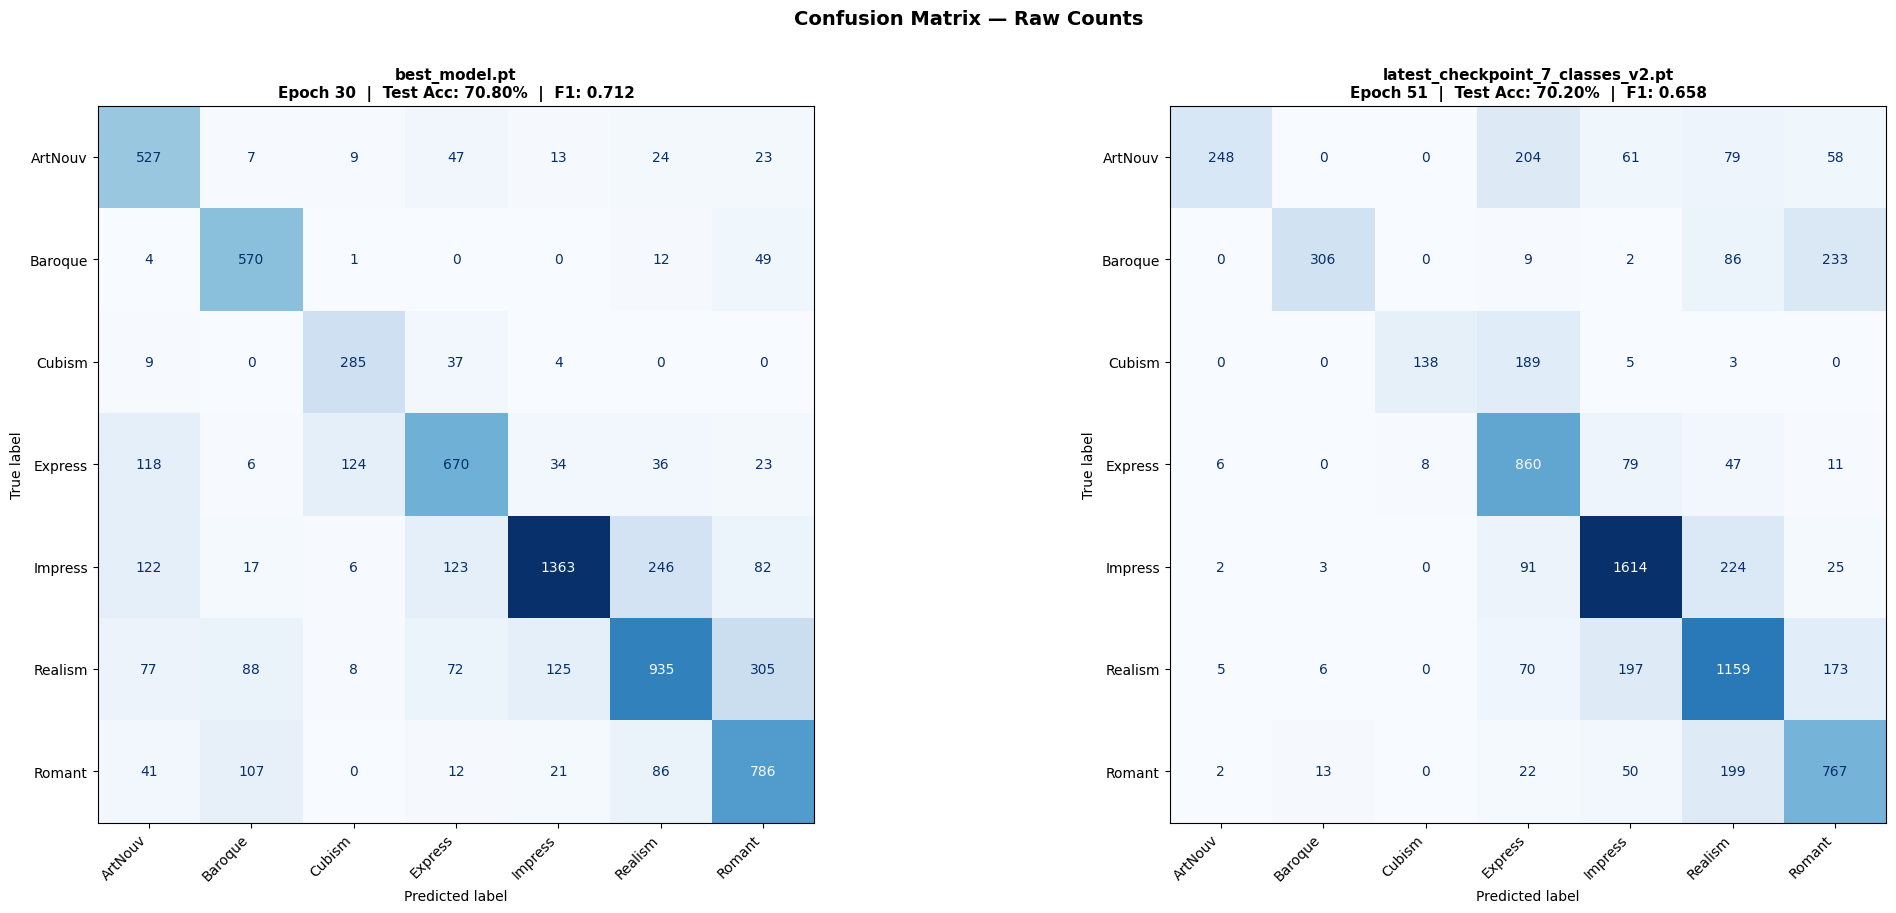

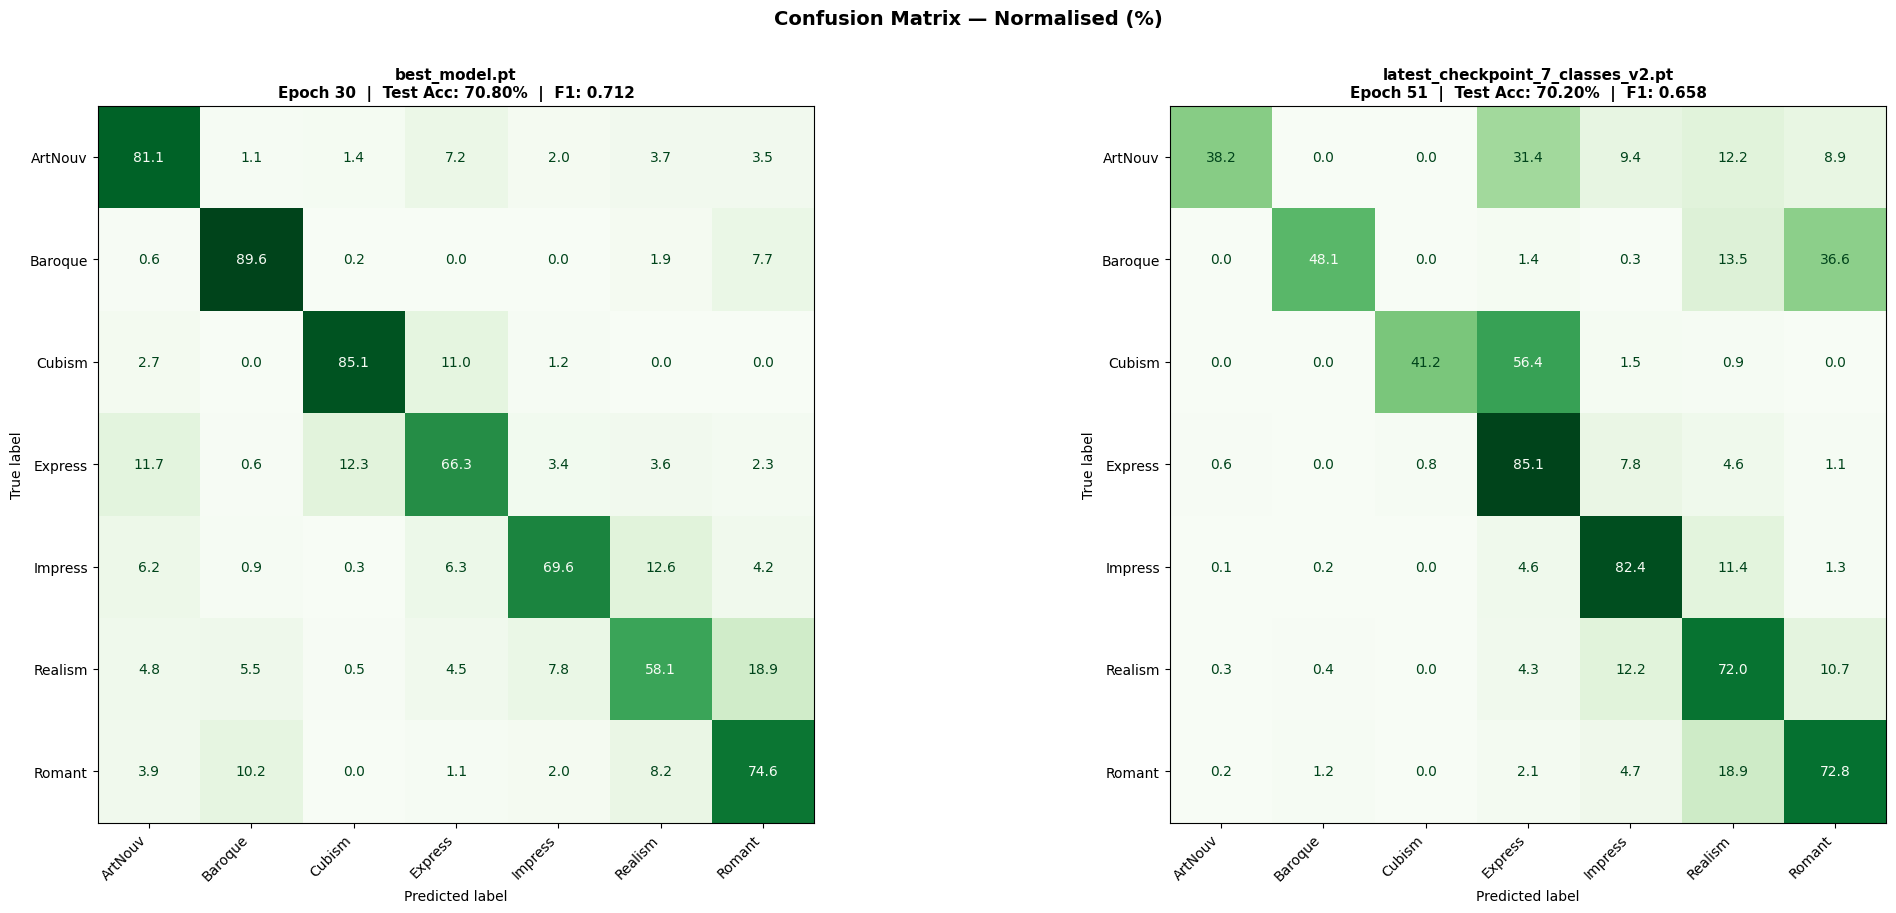


Saved to: C:\ArtStyle_Project\checkpoints_fresh\plots


In [13]:
# ============================================================
# CONFUSION MATRICES — best_model.pt vs latest checkpoint
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

PLOT_DIR = os.path.join(CONFIG['checkpoint_dir'], 'plots')
short_names = ['ArtNouv', 'Baroque', 'Cubism', 'Express', 'Impress', 'Realism', 'Romant']

def get_preds(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'], strict=False)
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            logits, _ = model(imgs)
            preds.extend(torch.argmax(logits, 1).cpu().numpy())
            targets.extend(labels.numpy())
    return np.array(preds), np.array(targets), ckpt.get('epoch'), ckpt.get('val_acc', 0)

ckpts = {
    'best_model.pt'                    : os.path.join(CONFIG['checkpoint_dir'], 'best_model.pt'),
    'latest_checkpoint_7_classes_v2.pt': os.path.join(CONFIG['checkpoint_dir'], 'latest_checkpoint_7_classes_v2.pt'),
}

results = {}
for name, path in ckpts.items():
    if os.path.exists(path):
        p, t, ep, va = get_preds(path)
        acc = accuracy_score(t, p)
        f1  = f1_score(t, p, average='macro')
        results[name] = {'preds': p, 'targets': t, 'epoch': ep,
                         'acc': acc, 'f1': f1, 'val_acc': va}
        print(f"{name} | epoch {ep} | test_acc {acc*100:.2f}% | F1 {f1:.4f}")

# Raw confusion matrices
fig, axes = plt.subplots(1, len(results), figsize=(11 * len(results), 9))
if len(results) == 1: axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm   = confusion_matrix(res['targets'], res['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=short_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f"{name}\nEpoch {res['epoch']}  |  Test Acc: {res['acc']*100:.2f}%  |  F1: {res['f1']:.3f}",
                 fontsize=11, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Confusion Matrix — Raw Counts', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'cm_raw_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Normalised confusion matrices
fig, axes = plt.subplots(1, len(results), figsize=(11 * len(results), 9))
if len(results) == 1: axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm      = confusion_matrix(res['targets'], res['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    disp    = ConfusionMatrixDisplay(np.round(cm_norm, 1), display_labels=short_names)
    disp.plot(ax=ax, cmap='Greens', values_format='.1f', colorbar=False)
    ax.set_title(f"{name}\nEpoch {res['epoch']}  |  Test Acc: {res['acc']*100:.2f}%  |  F1: {res['f1']:.3f}",
                 fontsize=11, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Confusion Matrix — Normalised (%)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'cm_normalised_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved to: {PLOT_DIR}")

In [11]:
# ============================================================
# CELL 5: Load best_model.pt — NO optimizer state
# ============================================================
best_path = os.path.join(CONFIG['checkpoint_dir'], 'best_model.pt')

checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=False)
status     = model.load_state_dict(checkpoint['model_state_dict'], strict=False)

start_epoch   = checkpoint.get('epoch', 30) + 1
best_val_loss = checkpoint.get('val_loss', float('inf'))
history       = {k: [] for k in
                 ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1']}

print(f"Loaded   : best_model.pt")
print(f"Epoch    : {checkpoint.get('epoch')}")
print(f"val_loss : {checkpoint.get('val_loss'):.4f}")
print(f"val_acc  : {checkpoint.get('val_acc'):.4f}")
print(f"Resuming from epoch : {start_epoch}")
print(f"Missing keys  : {len(status.missing_keys)}")
print(f"Unexpected    : {len(status.unexpected_keys)}")
print("Optimizer and scheduler will be RESET FRESH — not loaded from checkpoint")

Loaded   : best_model.pt
Epoch    : 30
val_loss : 1.0755
val_acc  : 0.7281
Resuming from epoch : 31
Missing keys  : 0
Unexpected    : 0
Optimizer and scheduler will be RESET FRESH — not loaded from checkpoint


In [12]:
import os

ckpt_dir = CONFIG['checkpoint_dir']
print(f"Checkpoint directory: {ckpt_dir}")
print("\nFiles found:")
for f in os.listdir(ckpt_dir):
    full = os.path.join(ckpt_dir, f)
    size = os.path.getsize(full) / 1e6
    print(f"  {f}  ({size:.0f} MB)")

Checkpoint directory: C:\ArtStyle_Project\checkpoints_fresh

Files found:
  best_model.pt  (189 MB)
  latest_checkpoint_7_classes_v2.pt  (566 MB)
  plots  (0 MB)
  runs  (0 MB)
  training_history.png  (0 MB)


Latest checkpoint  : epoch 50
History length     : 31 epochs
Epoch range        : 20 → 50
Best val_loss seen : 1.0755

Best epoch in history : 45
  val_loss : 1.3194
  val_acc  : 0.7564
  train_acc: 0.8374
  gap      : 8.1%


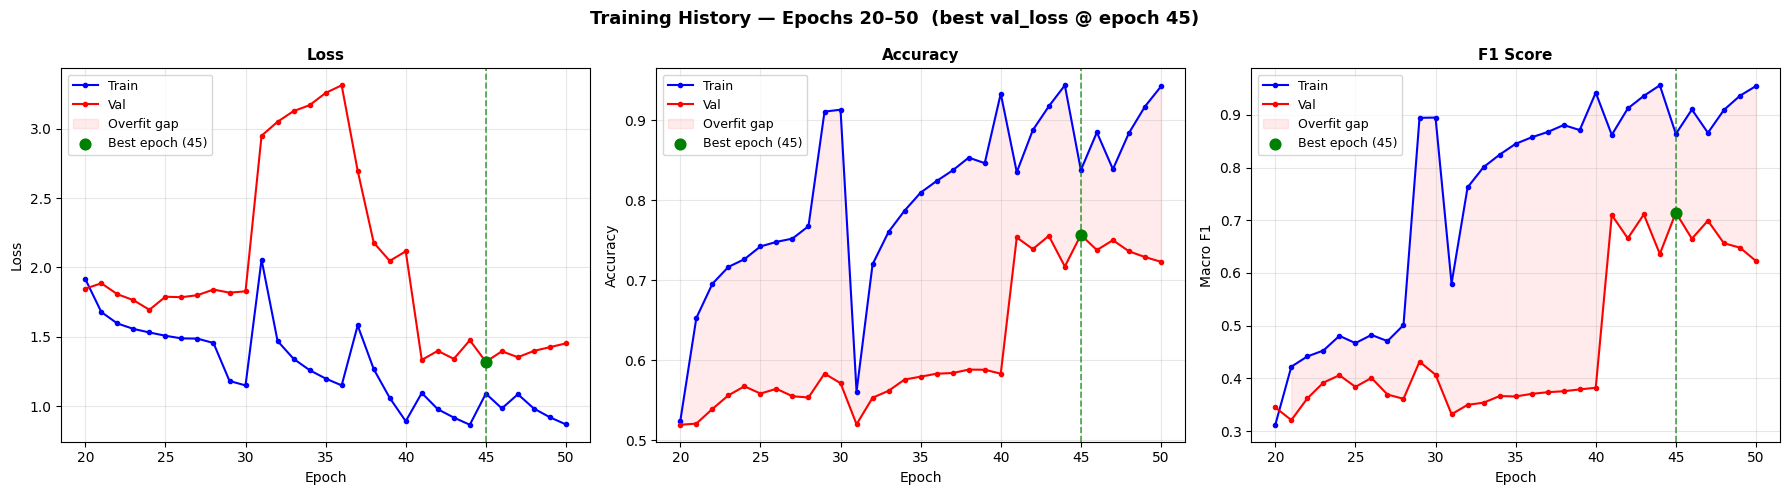

Saved: training_history.png


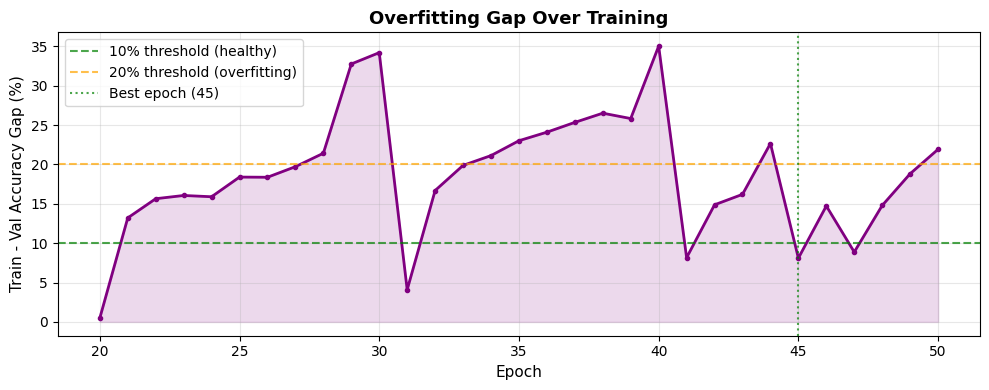

Saved: overfit_gap.png

All plots saved to: C:\ArtStyle_Project\checkpoints_fresh\plots


In [16]:
# ============================================================
# TRAINING HISTORY PLOTS — Latest Checkpoint
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PLOT_DIR = os.path.join(CONFIG['checkpoint_dir'], 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

# ── Load history from latest checkpoint ─────────────────────
latest_path = os.path.join(CONFIG['checkpoint_dir'], 'latest_checkpoint_7_classes_v2.pt')
ckpt        = torch.load(latest_path, map_location='cpu', weights_only=False)
history     = ckpt.get('history', {})
last_epoch  = ckpt.get('epoch', 0)
best_val_loss_saved = ckpt.get('best_val_loss', None)

train_loss = history.get('train_loss', [])
val_loss   = history.get('val_loss',   [])
train_acc  = history.get('train_acc',  [])
val_acc    = history.get('val_acc',    [])
train_f1   = history.get('train_f1',   [])
val_f1     = history.get('val_f1',     [])

n_epochs = len(train_loss)
epochs   = list(range(last_epoch - n_epochs + 1, last_epoch + 1))

print(f"Latest checkpoint  : epoch {last_epoch}")
print(f"History length     : {n_epochs} epochs")
print(f"Epoch range        : {epochs[0]} → {epochs[-1]}")
print(f"Best val_loss seen : {best_val_loss_saved:.4f}" if best_val_loss_saved else "")

# Find best epoch in history
best_idx      = int(np.argmin(val_loss))
best_epoch    = epochs[best_idx]
best_val_acc  = val_acc[best_idx]
best_val_loss_hist = val_loss[best_idx]

print(f"\nBest epoch in history : {best_epoch}")
print(f"  val_loss : {best_val_loss_hist:.4f}")
print(f"  val_acc  : {best_val_acc:.4f}")
print(f"  train_acc: {train_acc[best_idx]:.4f}")
print(f"  gap      : {(train_acc[best_idx]-val_acc[best_idx])*100:.1f}%")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Training History — Epochs {epochs[0]}–{epochs[-1]}  '
             f'(best val_loss @ epoch {best_epoch})',
             fontsize=13, fontweight='bold')

plot_cfg = [
    (axes[0], train_loss, val_loss,  'Loss',     'Loss'),
    (axes[1], train_acc,  val_acc,   'Accuracy', 'Accuracy'),
    (axes[2], train_f1,   val_f1,    'F1 Score', 'Macro F1'),
]

for ax, tr, vl, title, ylabel in plot_cfg:
    ax.plot(epochs, tr, 'b-o', markersize=3, linewidth=1.5, label='Train')
    ax.plot(epochs, vl, 'r-o', markersize=3, linewidth=1.5, label='Val')

    # Shade gap between train and val
    ax.fill_between(epochs, tr, vl,
                    where=[t > v for t, v in zip(tr, vl)],
                    alpha=0.08, color='red', label='Overfit gap')

    # Mark best epoch
    best_tr_val = tr[best_idx]
    best_vl_val = vl[best_idx]
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=1.2)
    ax.scatter([best_epoch], [best_vl_val], color='green', zorder=5, s=60,
               label=f'Best epoch ({best_epoch})')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'training_history.png'), dpi=150)
plt.show()
print("Saved: training_history.png")

# ── Plot 2: Train-Val Gap over epochs ───────────────────────
gaps = [(t - v) * 100 for t, v in zip(train_acc, val_acc)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epochs, gaps, 'purple', linewidth=2, marker='o', markersize=3)
ax.fill_between(epochs, gaps, alpha=0.15, color='purple')
ax.axhline(y=10, color='green',  linestyle='--', alpha=0.7, label='10% threshold (healthy)')
ax.axhline(y=20, color='orange', linestyle='--', alpha=0.7, label='20% threshold (overfitting)')
ax.axvline(x=best_epoch, color='green', linestyle=':', alpha=0.7,
           label=f'Best epoch ({best_epoch})')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Train - Val Accuracy Gap (%)', fontsize=11)
ax.set_title('Overfitting Gap Over Training', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'overfit_gap.png'), dpi=150)
plt.show()
print("Saved: overfit_gap.png")

print(f"\nAll plots saved to: {PLOT_DIR}")

In [13]:
import os, torch

ckpt_dir = CONFIG['checkpoint_dir']

for fname in ['best_model.pt', 'latest_checkpoint_7_classes_v2.pt']:
    path = os.path.join(ckpt_dir, fname)
    print(f"\n{'='*50}")
    print(f"File: {fname}")
    ckpt = torch.load(path, map_location='cpu')
    print(f"Keys: {list(ckpt.keys())}")
    print(f"Epoch          : {ckpt.get('epoch', 'N/A')}")
    print(f"val_loss       : {ckpt.get('val_loss', 'N/A')}")
    print(f"best_val_loss  : {ckpt.get('best_val_loss', 'N/A')}")

    if 'history' in ckpt:
        h = ckpt['history']
        print(f"History epochs : {len(h.get('val_acc', []))}")
        print(f"Val acc history: {[round(x,4) for x in h.get('val_acc',[])]}")
    
    if 'optimizer_state_dict' in ckpt:
        print("Optimizer LRs:")
        for i, pg in enumerate(ckpt['optimizer_state_dict']['param_groups']):
            print(f"  Group {i}: {pg['lr']:.2e}")
    else:
        print("No optimizer state in this checkpoint")

print(f"\n{'='*50}")
print("Class distribution:")
for c, n in class_counts.items():
    print(f"  {c:<25}: {n:,}")


File: best_model.pt
Keys: ['epoch', 'model_state_dict', 'val_loss', 'val_acc', 'val_f1']
Epoch          : 30
val_loss       : 1.0754906663810628
best_val_loss  : N/A
No optimizer state in this checkpoint

File: latest_checkpoint_7_classes_v2.pt


C:\Users\Admin\AppData\Local\Temp\ipykernel_1752\3176329471.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location='cpu')


Keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'val_loss', 'best_val_loss', 'history']
Epoch          : 44
val_loss       : 1.4746943552063425
best_val_loss  : 1.0754906663810628
History epochs : 25
Val acc history: [0.5191, 0.5205, 0.5388, 0.5558, 0.5671, 0.5581, 0.564, 0.5547, 0.5532, 0.583, 0.571, 0.5196, 0.5529, 0.5615, 0.5756, 0.5792, 0.5829, 0.5837, 0.588, 0.5879, 0.5829, 0.7533, 0.7387, 0.7552, 0.7169]
Optimizer LRs:
  Group 0: 7.83e-06
  Group 1: 7.83e-06
  Group 2: 4.90e-06
  Group 3: 1.95e-05
  Group 4: 2.93e-05

Class distribution:
  Art_Nouveau_Modern       : 4,334
  Baroque                  : 4,240
  Cubism                   : 2,235
  Expressionism            : 6,736
  Impressionism            : 13,060
  Realism                  : 10,733
  Romanticism              : 7,019


Loaded  : best_model.pt  (epoch 30)
Val acc : 0.7281499862145023
Val loss: 1.0755

Running inference on test set...

  Test Accuracy  : 72.08%
  Test F1 (macro): 0.7241

Per-class breakdown:
                    precision    recall  f1-score   support

Art_Nouveau_Modern      0.630     0.795     0.703       650
           Baroque      0.730     0.882     0.799       636
            Cubism      0.680     0.830     0.747       335
     Expressionism      0.719     0.679     0.698      1011
     Impressionism      0.863     0.729     0.791      1959
           Realism      0.687     0.604     0.643      1610
       Romanticism      0.638     0.746     0.688      1053

          accuracy                          0.721      7254
         macro avg      0.707     0.752     0.724      7254
      weighted avg      0.730     0.721     0.721      7254



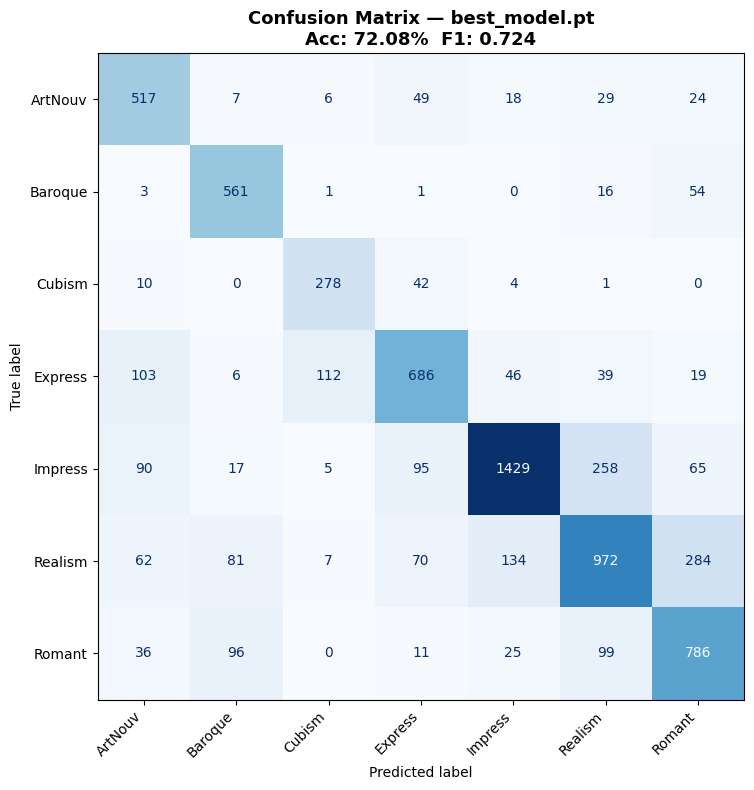

Saved: confusion_matrix_best.png


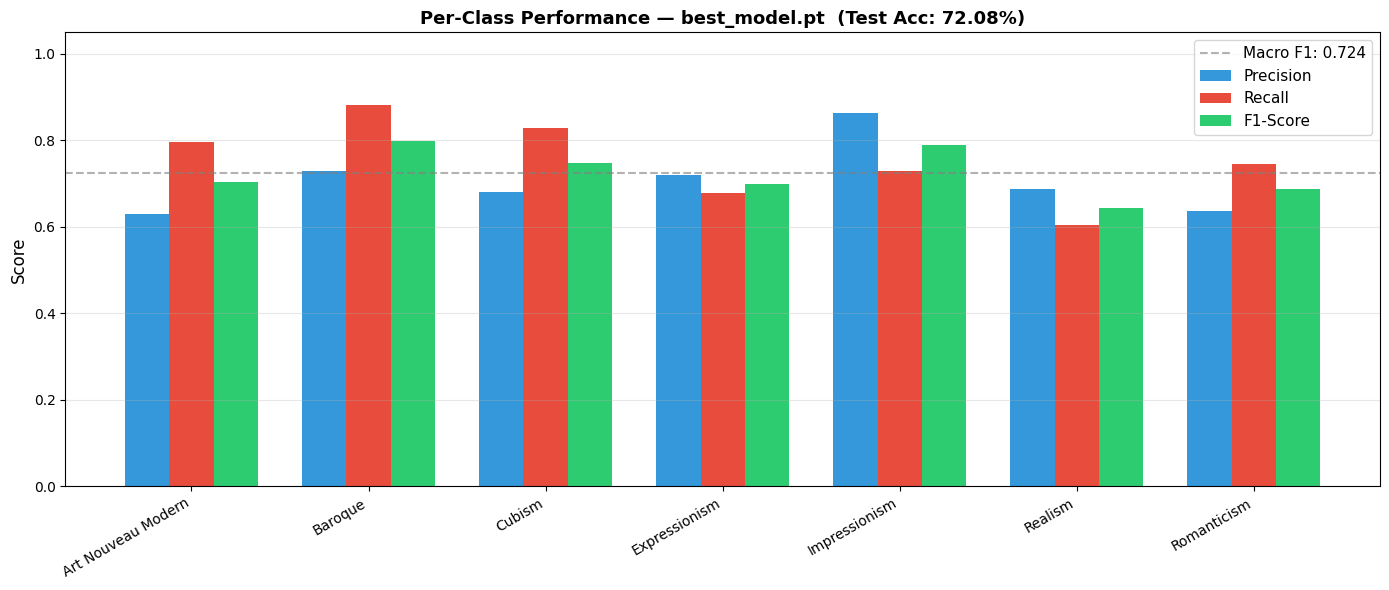

Saved: per_class_performance_best.png


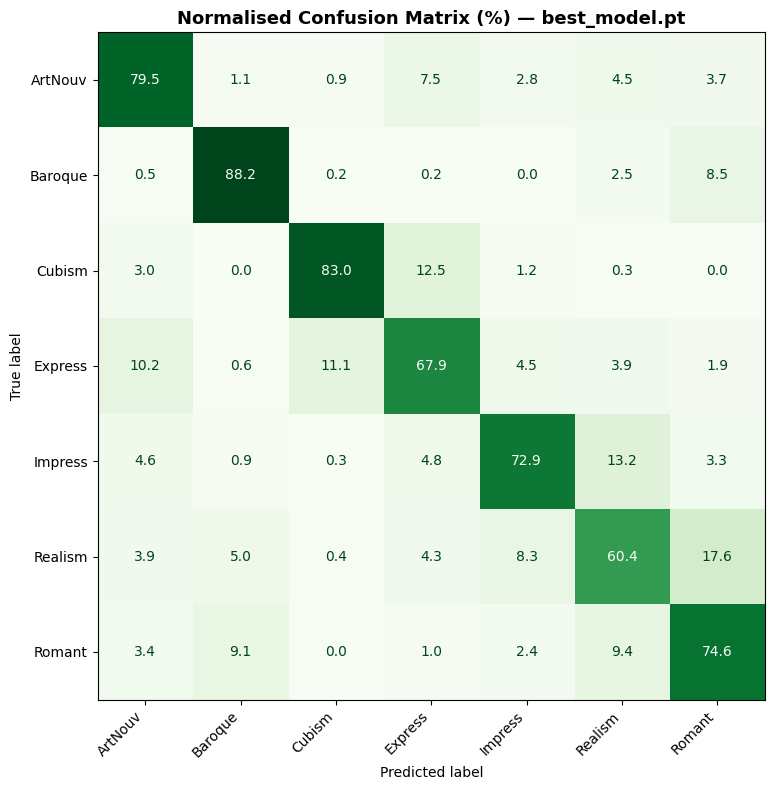

Saved: confusion_matrix_normalised.png


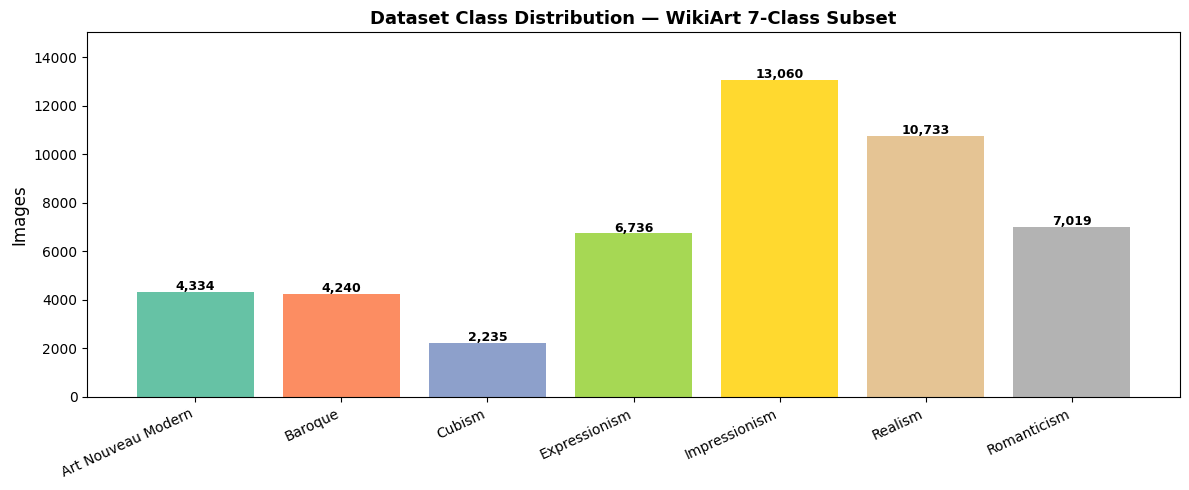

Saved: dataset_distribution.png

All plots saved to: C:\ArtStyle_Project\checkpoints_fresh\plots


In [13]:
# ============================================================
# TEST EVALUATION + PLOTS — best_model.pt
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

PLOT_DIR = os.path.join(CONFIG['checkpoint_dir'], 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

# ── Load & Infer ────────────────────────────────────────────
best_path = os.path.join(CONFIG['checkpoint_dir'], 'best_model.pt')
ckpt      = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'], strict=False)
model.eval()

print(f"Loaded  : best_model.pt  (epoch {ckpt.get('epoch')})")
print(f"Val acc : {ckpt.get('val_acc', 'N/A')}")
print(f"Val loss: {ckpt.get('val_loss'):.4f}")
print("\nRunning inference on test set...")

all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits, _ = model(imgs)
        all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
        all_targets.extend(labels.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

test_acc = accuracy_score(all_targets, all_preds)
test_f1  = f1_score(all_targets, all_preds, average='macro')

print(f"\n{'='*45}")
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Test F1 (macro): {test_f1:.4f}")
print(f"{'='*45}")
print(f"\nPer-class breakdown:")
print(classification_report(all_targets, all_preds,
                             target_names=CLASS_NAMES, digits=3))

short_names = ['ArtNouv', 'Baroque', 'Cubism', 'Express', 'Impress', 'Realism', 'Romant']

# ── Plot 1: Confusion Matrix ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
cm   = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=short_names)
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title(f'Confusion Matrix — best_model.pt\nAcc: {test_acc*100:.2f}%  F1: {test_f1:.3f}',
             fontsize=13, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'confusion_matrix_best.png'), dpi=150)
plt.show()
print("Saved: confusion_matrix_best.png")

# ── Plot 2: Per-class Precision / Recall / F1 ────────────────
report = classification_report(all_targets, all_preds,
                                target_names=CLASS_NAMES, output_dict=True)
precs   = [report[c]['precision'] for c in CLASS_NAMES]
recalls = [report[c]['recall']    for c in CLASS_NAMES]
f1s     = [report[c]['f1-score']  for c in CLASS_NAMES]

x, w = np.arange(len(CLASS_NAMES)), 0.25
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w, precs,   w, label='Precision', color='#3498db')
ax.bar(x,     recalls, w, label='Recall',    color='#e74c3c')
ax.bar(x + w, f1s,     w, label='F1-Score',  color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ') for c in CLASS_NAMES],
                   rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Per-Class Performance — best_model.pt  (Test Acc: {test_acc*100:.2f}%)',
             fontsize=13, fontweight='bold')
ax.axhline(y=test_f1, color='gray', linestyle='--', alpha=0.6,
           label=f'Macro F1: {test_f1:.3f}')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'per_class_performance_best.png'), dpi=150)
plt.show()
print("Saved: per_class_performance_best.png")

# ── Plot 3: Normalised Confusion Matrix (%) ──────────────────
fig, ax = plt.subplots(figsize=(10, 8))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
disp2   = ConfusionMatrixDisplay(np.round(cm_norm, 1), display_labels=short_names)
disp2.plot(ax=ax, cmap='Greens', values_format='.1f', colorbar=False)
ax.set_title('Normalised Confusion Matrix (%) — best_model.pt',
             fontsize=13, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'confusion_matrix_normalised.png'), dpi=150)
plt.show()
print("Saved: confusion_matrix_normalised.png")

# ── Plot 4: Dataset Distribution ─────────────────────────────
counts  = [class_counts.get(c, 0) for c in CLASS_NAMES]
colors  = plt.cm.Set2(np.linspace(0, 1, len(CLASS_NAMES)))
fig, ax = plt.subplots(figsize=(12, 5))
bars    = ax.bar([c.replace('_', ' ') for c in CLASS_NAMES], counts, color=colors)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
            f'{count:,}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Images', fontsize=12)
ax.set_ylim(0, max(counts) * 1.15)
ax.set_title('Dataset Class Distribution — WikiArt 7-Class Subset',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'dataset_distribution.png'), dpi=150)
plt.show()
print("Saved: dataset_distribution.png")

print(f"\nAll plots saved to: {PLOT_DIR}")

Loaded   : gap_under10_epoch54.pt
Epoch    : 54
Train acc (saved): 0.8334
Val acc  (saved): 0.7693
Gap      (saved): 6.42%

Running inference on test set...

  Test Accuracy  : 71.52%
  Test F1 (macro): 0.6880

Per-class breakdown:
                    precision    recall  f1-score   support

Art_Nouveau_Modern      0.949     0.458     0.618       650
           Baroque      0.929     0.538     0.681       636
            Cubism      0.926     0.487     0.638       335
     Expressionism      0.625     0.828     0.712      1011
     Impressionism      0.805     0.827     0.816      1959
           Realism      0.652     0.706     0.678      1610
       Romanticism      0.608     0.751     0.672      1053

          accuracy                          0.715      7254
         macro avg      0.785     0.656     0.688      7254
      weighted avg      0.747     0.715     0.712      7254



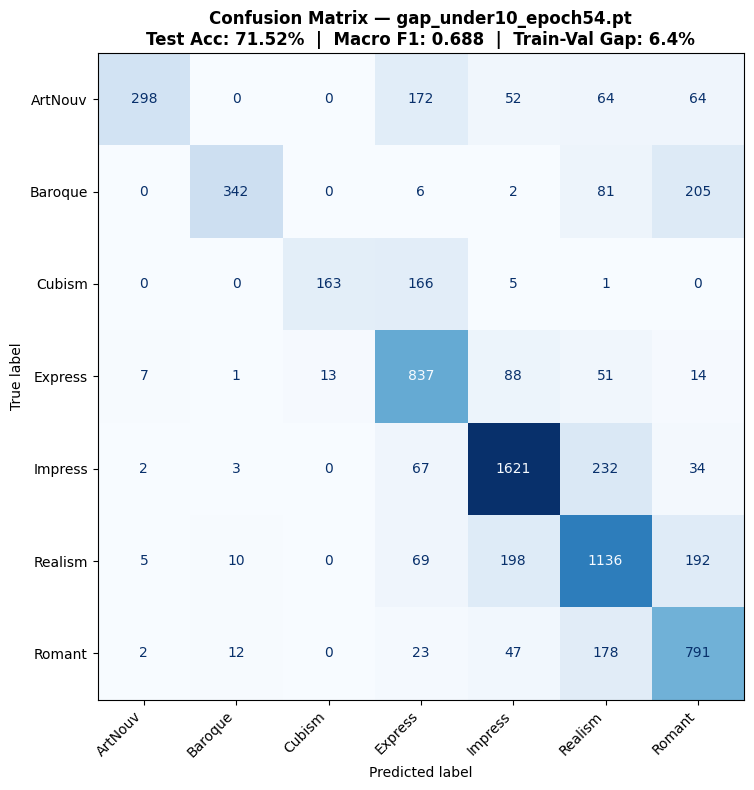

Saved: confusion_matrix_epoch54.png


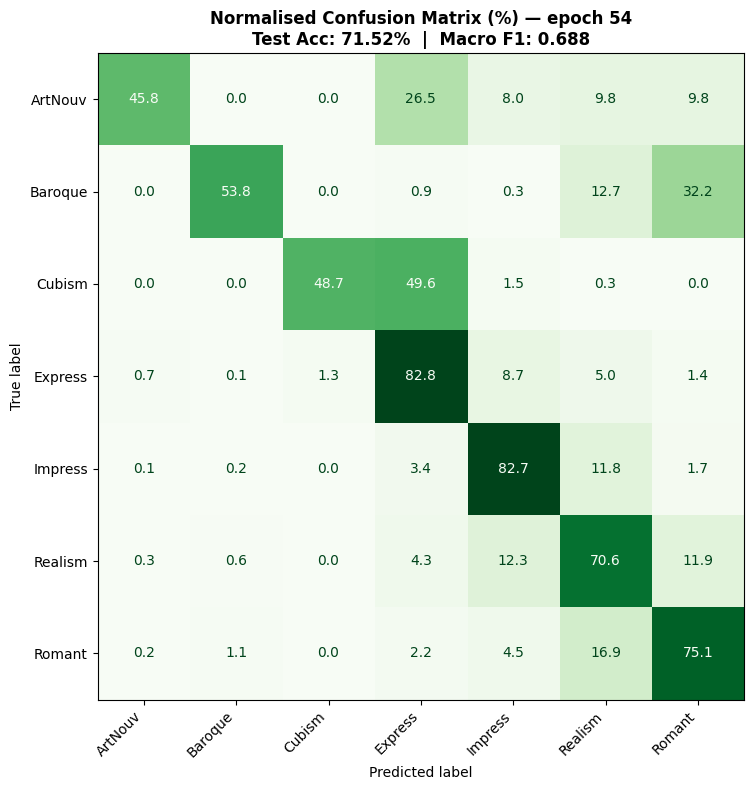

Saved: confusion_matrix_normalised_epoch54.png


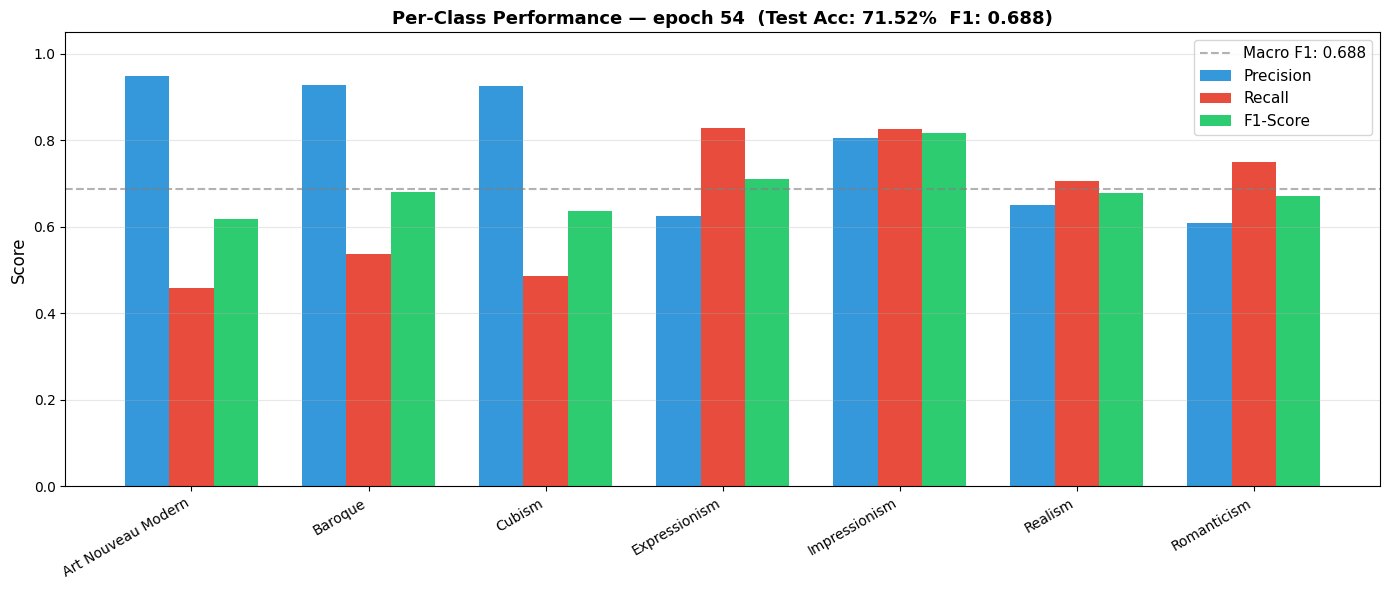

Saved: per_class_epoch54.png

All plots saved to: C:\ArtStyle_Project\checkpoints_fresh\plots


In [14]:
# ============================================================
# TEST EVALUATION — gap_under10_epoch54.pt
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

PLOT_DIR = os.path.join(CONFIG['checkpoint_dir'], 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)
short_names = ['ArtNouv','Baroque','Cubism','Express','Impress','Realism','Romant']

# ── Load checkpoint ──────────────────────────────────────────
ckpt_path = os.path.join(CONFIG['checkpoint_dir'], 'gap_under10_epoch54.pt')
ckpt      = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'], strict=False)
model.eval()

epoch     = ckpt.get('epoch', 54)
val_acc_s = ckpt.get('val_acc', None)
train_acc_s = ckpt.get('train_acc', None)
gap_s     = ckpt.get('gap', None)

print(f"Loaded   : gap_under10_epoch54.pt")
print(f"Epoch    : {epoch}")
print(f"Train acc (saved): {train_acc_s:.4f}" if train_acc_s else "")
print(f"Val acc  (saved): {val_acc_s:.4f}"   if val_acc_s   else "")
print(f"Gap      (saved): {gap_s:.2f}%"      if gap_s       else "")
print("\nRunning inference on test set...")

# ── Inference ────────────────────────────────────────────────
all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits, _ = model(imgs)
        all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
        all_targets.extend(labels.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

test_acc = accuracy_score(all_targets, all_preds)
test_f1  = f1_score(all_targets, all_preds, average='macro')

print(f"\n{'='*45}")
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Test F1 (macro): {test_f1:.4f}")
print(f"{'='*45}")
print(f"\nPer-class breakdown:")
print(classification_report(all_targets, all_preds,
                             target_names=CLASS_NAMES, digits=3))

# ── Plot 1: Confusion Matrix (raw counts) ────────────────────
cm   = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=short_names)
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title(f'Confusion Matrix — gap_under10_epoch{epoch}.pt\n'
             f'Test Acc: {test_acc*100:.2f}%  |  Macro F1: {test_f1:.3f}'
             + (f'  |  Train-Val Gap: {gap_s:.1f}%' if gap_s else ''),
             fontsize=12, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, f'confusion_matrix_epoch{epoch}.png'), dpi=150)
plt.show()
print(f"Saved: confusion_matrix_epoch{epoch}.png")

# ── Plot 2: Normalised Confusion Matrix (%) ──────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
fig, ax = plt.subplots(figsize=(10, 8))
disp2   = ConfusionMatrixDisplay(np.round(cm_norm, 1), display_labels=short_names)
disp2.plot(ax=ax, cmap='Greens', values_format='.1f', colorbar=False)
ax.set_title(f'Normalised Confusion Matrix (%) — epoch {epoch}\n'
             f'Test Acc: {test_acc*100:.2f}%  |  Macro F1: {test_f1:.3f}',
             fontsize=12, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, f'confusion_matrix_normalised_epoch{epoch}.png'), dpi=150)
plt.show()
print(f"Saved: confusion_matrix_normalised_epoch{epoch}.png")

# ── Plot 3: Per-class Precision / Recall / F1 ────────────────
report  = classification_report(all_targets, all_preds,
                                 target_names=CLASS_NAMES, output_dict=True)
precs   = [report[c]['precision'] for c in CLASS_NAMES]
recalls = [report[c]['recall']    for c in CLASS_NAMES]
f1s     = [report[c]['f1-score']  for c in CLASS_NAMES]

x, w = np.arange(len(CLASS_NAMES)), 0.25
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w, precs,   w, label='Precision', color='#3498db')
ax.bar(x,     recalls, w, label='Recall',    color='#e74c3c')
ax.bar(x + w, f1s,     w, label='F1-Score',  color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ') for c in CLASS_NAMES],
                   rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Per-Class Performance — epoch {epoch}  '
             f'(Test Acc: {test_acc*100:.2f}%  F1: {test_f1:.3f})',
             fontsize=13, fontweight='bold')
ax.axhline(y=test_f1, color='gray', linestyle='--', alpha=0.6,
           label=f'Macro F1: {test_f1:.3f}')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, f'per_class_epoch{epoch}.png'), dpi=150)
plt.show()
print(f"Saved: per_class_epoch{epoch}.png")

print(f"\nAll plots saved to: {PLOT_DIR}")

In [15]:
# ============================================================
# TEST EVALUATION — best_model.pt
# ============================================================
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

best_path = os.path.join(CONFIG['checkpoint_dir'], 'best_model.pt')
ckpt      = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'], strict=False)
model.eval()

print(f"Loaded  : best_model.pt  (epoch {ckpt.get('epoch')})")
print(f"Val acc : {ckpt.get('val_acc', 'N/A')}")
print(f"Val loss: {ckpt.get('val_loss'):.4f}")
print("\nRunning inference on test set...")

all_preds, all_targets = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        logits, _ = model(imgs)
        all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
        all_targets.extend(labels.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

test_acc = accuracy_score(all_targets, all_preds)
test_f1  = f1_score(all_targets, all_preds, average='macro')

print(f"\n{'='*45}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test F1 (macro): {test_f1:.4f}")
print(f"{'='*45}")
print(f"\nPer-class breakdown:")
print(classification_report(all_targets, all_preds,
                             target_names=CLASS_NAMES, digits=3))

Loaded  : best_model.pt  (epoch 30)
Val acc : 0.7281499862145023
Val loss: 1.0755

Running inference on test set...

  Test Accuracy : 72.08%
  Test F1 (macro): 0.7241

Per-class breakdown:
                    precision    recall  f1-score   support

Art_Nouveau_Modern      0.630     0.795     0.703       650
           Baroque      0.730     0.882     0.799       636
            Cubism      0.680     0.830     0.747       335
     Expressionism      0.719     0.679     0.698      1011
     Impressionism      0.863     0.729     0.791      1959
           Realism      0.687     0.604     0.643      1610
       Romanticism      0.638     0.746     0.688      1053

          accuracy                          0.721      7254
         macro avg      0.707     0.752     0.724      7254
      weighted avg      0.730     0.721     0.721      7254



In [18]:
# ============================================================
# CELL 9: Live Prediction — Upload any artwork image
# ============================================================
import torch.nn.functional as F
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

# ── Load checkpoint ──────────────────────────────────────────
CKPT_NAME = 'gap_under10_epoch54.pt'  # ← change to 'best_model.pt' if preferred
ckpt_path = os.path.join(CONFIG['checkpoint_dir'], CKPT_NAME)
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'], strict=False)
    print(f"Loaded : {CKPT_NAME}  (epoch {ckpt.get('epoch','?')})")
else:
    print(f"Checkpoint not found: {ckpt_path} — using currently loaded weights.")

transform_infer = T.Compose([
    T.Resize((224, 224)), T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Upload widget ─────────────────────────────────────────────
upload = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=False,
    description='Upload Painting',
    layout=widgets.Layout(width='220px')
)
btn    = widgets.Button(
    description='Predict',
    button_style='success',
    layout=widgets.Layout(width='120px')
)
output = widgets.Output()

def on_predict(b):
    with output:
        clear_output(wait=True)

        if not upload.value:
            print("Please upload an image first.")
            return

        # Read uploaded bytes — compatible with ipywidgets v7 and v8
        try:
            # ipywidgets v8: upload.value is a tuple
            uploaded_file = upload.value[0]
            img_bytes = uploaded_file['content'] if isinstance(uploaded_file, dict) \
                        else bytes(uploaded_file.content)
        except (KeyError, AttributeError):
            # ipywidgets v7: upload.value is a dict keyed by filename
            uploaded_file = list(upload.value.values())[0]
            img_bytes = uploaded_file['content']

        img_pil = Image.open(io.BytesIO(img_bytes)).convert('RGB')

        # ── Inference ─────────────────────────────────────────
        input_tensor = transform_infer(img_pil).unsqueeze(0).to(DEVICE)
        model.eval()
        with torch.no_grad():
            logits, _ = model(input_tensor)
            probs     = F.softmax(logits, dim=1)[0].cpu().numpy()

        sorted_idx    = np.argsort(probs)[::-1]
        predicted_cls = CLASS_NAMES[sorted_idx[0]].replace('_', ' ')
        top_conf      = probs[sorted_idx[0]] * 100

        # ── Print results ──────────────────────────────────────
        print(f"\n{'='*48}")
        print(f"  Prediction  : {predicted_cls}")
        print(f"  Confidence  : {top_conf:.2f}%")
        print(f"{'='*48}")
        for i in range(len(CLASS_NAMES)):
            idx  = sorted_idx[i]
            name = CLASS_NAMES[idx].replace('_', ' ')
            bar  = chr(9608) * int(probs[idx] * 40)
            print(f"  {name:<22}: {probs[idx]*100:5.2f}%  {bar}")

        # ── Plot ───────────────────────────────────────────────
        sorted_names = [CLASS_NAMES[i].replace('_', ' ') for i in sorted_idx]
        sorted_probs = [probs[i] for i in sorted_idx]
        bar_colors   = ['#2ecc71' if i == 0 else '#3498db'
                        for i in range(len(CLASS_NAMES))]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle(f'ArtStyleHybrid V5 — Live Prediction  [{CKPT_NAME}]',
                     fontsize=13, fontweight='bold')

        ax1.imshow(img_pil)
        ax1.set_title('Input Image', fontsize=12)
        ax1.axis('off')

        bars_h = ax2.barh(range(len(CLASS_NAMES)), sorted_probs, color=bar_colors)
        ax2.set_yticks(range(len(CLASS_NAMES)))
        ax2.set_yticklabels(sorted_names, fontsize=11)
        ax2.set_xlabel('Confidence Score', fontsize=11)
        ax2.set_xlim(0, 1.05)
        ax2.set_title(f'Prediction: {predicted_cls}  ({top_conf:.1f}%)',
                      fontsize=12, fontweight='bold', color='#2ecc71')
        ax2.invert_yaxis()
        ax2.grid(axis='x', alpha=0.3)
        for bar, prob in zip(bars_h, sorted_probs):
            ax2.text(bar.get_width() + 0.01,
                     bar.get_y() + bar.get_height() / 2,
                     f'{prob*100:.1f}%', va='center', fontsize=10)

        plt.tight_layout()
        PLOT_DIR = os.path.join(CONFIG['checkpoint_dir'], 'plots')
        os.makedirs(PLOT_DIR, exist_ok=True)
        plt.savefig(os.path.join(PLOT_DIR, 'prediction_result.png'), dpi=150)
        plt.show()
        print(f"\nSaved: prediction_result.png")

btn.on_click(on_predict)

print("Upload a painting and click Predict:")
display(widgets.HBox([upload, btn]), output)

Loaded : gap_under10_epoch54.pt  (epoch 54)
Upload a painting and click Predict:


Output()